# Cross-Modal InFOM Method A/B Monitor

Tracks State-Distilled Method A plus TCN/InfoNCE Method B smoke/full runs, including Slurm status, checkpoints, TensorBoard paths, and alignment diagnostics.


In [1]:
from __future__ import annotations

import json
import os
import re
import shlex
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import ipywidgets as widgets
except Exception as exc:  # Notebook remains useful without widgets.
    widgets = None
    print(f"ipywidgets unavailable: {exc}")

REPO_ROOT = Path("/home/nick/infom-learning-from-obs")
if not REPO_ROOT.exists():
    REPO_ROOT = Path.cwd().resolve()

SSH_HOST = "bhuo_umass_edu@unity"
SSH_AUTH_SOCK = os.environ.get("SSH_AUTH_SOCK", "/run/user/1000/gcr/ssh")
CACHE_ROOT = REPO_ROOT / "output" / "jupyter-notebook" / "cache" / "state_distilled_method_a_monitor"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

RUNS = {
    "smoke": {
        "job_id": "56857200",
        "label": "25k full-data smoke",
        "remote_root": "/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_diag_20260506_172510",
        "train_rel": "runs/state_distilled_method_a_diagnostic/task1_seed0_25kpre_0kft/pretraining_train.csv",
        "tensorboard_rel": "runs/state_distilled_method_a_diagnostic/task1_seed0_25kpre_0kft/tensorboard",
        "checkpoint_rel": "runs/state_distilled_method_a_diagnostic/task1_seed0_25kpre_0kft/checkpoints",
        "expected_final_step": 25_000,
        "checkpoint_interval": 5_000,
        "checkpoint_keep": 4,
    },
    "full": {
        "job_id": "56857944",
        "label": "1M pretraining",
        "remote_root": "/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_diag_20260506_173753",
        "train_rel": "runs/state_distilled_method_a_diagnostic/task1_seed0_1000kpre_0kft/pretraining_train.csv",
        "tensorboard_rel": "runs/state_distilled_method_a_diagnostic/task1_seed0_1000kpre_0kft/tensorboard",
        "checkpoint_rel": "runs/state_distilled_method_a_diagnostic/task1_seed0_1000kpre_0kft/checkpoints",
        "expected_final_step": 1_000_000,
        "checkpoint_interval": 50_000,
        "checkpoint_keep": 5,
    },
}

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True})
print(f"Repo root: {REPO_ROOT}")
print(f"Local artifact cache: {CACHE_ROOT}")


Repo root: /home/nick/infom-learning-from-obs
Local artifact cache: /home/nick/infom-learning-from-obs/output/jupyter-notebook/cache/state_distilled_method_a_monitor


## Refresh Unity Artifacts

The refresh cell copies only analysis-sized files: CSV logs, Slurm stdout/stderr, JSON config/probe files, and TensorBoard event files. It explicitly excludes checkpoint pickle payloads. Checkpoint status is collected through a remote `find` listing instead.


In [2]:
def _env() -> dict[str, str]:
    env = os.environ.copy()
    env["SSH_AUTH_SOCK"] = SSH_AUTH_SOCK
    return env


def run_command(cmd: list[str], *, timeout: int = 120, check: bool = False) -> subprocess.CompletedProcess:
    proc = subprocess.run(
        cmd,
        cwd=REPO_ROOT,
        env=_env(),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if check and proc.returncode != 0:
        raise RuntimeError("Command failed:\n" + " ".join(shlex.quote(part) for part in cmd) + "\n" + proc.stdout)
    return proc


def ssh(command: str, *, timeout: int = 120, check: bool = False) -> subprocess.CompletedProcess:
    return run_command(["ssh", SSH_HOST, command], timeout=timeout, check=check)


def rsync_small_artifacts(name: str, spec: dict) -> dict:
    local_root = CACHE_ROOT / name
    local_root.mkdir(parents=True, exist_ok=True)
    remote_root = spec["remote_root"].rstrip("/") + "/"
    cmd = [
        "rsync",
        "-az",
        "--prune-empty-dirs",
        "--include=*/",
        "--include=*.csv",
        "--include=*.out",
        "--include=*.err",
        "--include=*.json",
        "--include=events.out.tfevents.*",
        "--exclude=*.pkl",
        "--exclude=*",
        f"{SSH_HOST}:{remote_root}",
        str(local_root) + "/",
    ]
    proc = run_command(cmd, timeout=240)
    return {"run": name, "returncode": proc.returncode, "output": proc.stdout.strip(), "local_root": str(local_root)}


def remote_checkpoint_listing(name: str, spec: dict) -> list[dict]:
    checkpoint_dir = f"{spec['remote_root'].rstrip('/')}/{spec['checkpoint_rel']}"
    command = (
        f"find {shlex.quote(checkpoint_dir)} -maxdepth 1 -type f "
        "-printf '%TY-%Tm-%Td %TH:%TM:%TS %f %s\\n' 2>/dev/null | sort"
    )
    proc = ssh(command, timeout=60)
    rows = []
    for line in proc.stdout.splitlines():
        match = re.match(r"(\d{4}-\d{2}-\d{2}) (\d{2}:\d{2}:\d{2}(?:\.\d+)?) (\S+) (\d+)$", line.strip())
        if match:
            rows.append({
                "run": name,
                "date": match.group(1),
                "time": match.group(2),
                "file": match.group(3),
                "bytes": int(match.group(4)),
            })
    listing_path = CACHE_ROOT / name / "checkpoint_listing.json"
    listing_path.parent.mkdir(parents=True, exist_ok=True)
    listing_path.write_text(json.dumps(rows, indent=2, sort_keys=True) + "\n")
    return rows


def slurm_status(job_id: str) -> str:
    quoted_job = shlex.quote(job_id)
    command = (
        "echo SQUEUE_ACTIVE; "
        f"squeue -j {quoted_job} -o '%.18i %.12P %.24j %.8T %.10M %.10l %.6D %.20q %R' 2>/dev/null || true; "
        "echo; echo SACCT_HISTORY; "
        f"sacct -j {quoted_job} --format=JobID,JobName%30,Partition,QOS,State,ExitCode,Elapsed,Timelimit,AllocTRES%80,NodeList -P"
    )
    return ssh(command, timeout=60).stdout


def refresh_all() -> pd.DataFrame:
    rows = []
    for name, spec in RUNS.items():
        sync_result = rsync_small_artifacts(name, spec)
        checkpoints = remote_checkpoint_listing(name, spec)
        status = slurm_status(spec["job_id"])
        status_path = CACHE_ROOT / name / "slurm_status.txt"
        status_path.write_text(status)
        rows.append({
            "run": name,
            "job_id": spec["job_id"],
            "rsync_code": sync_result["returncode"],
            "checkpoint_files": len(checkpoints),
            "local_root": sync_result["local_root"],
            "status_head": " | ".join(status.splitlines()[:3]),
        })
    return pd.DataFrame(rows)

refresh_df = refresh_all()
display(refresh_df)


,run,job_id,rsync_code,checkpoint_files,local_root,status_head
0,smoke,56857200,0,5,/home/nick/infom-learning-from-obs/output/jupy...,SQUEUE_ACTIVE | | SACCT_HISTORY
1,full,56857944,0,6,/home/nick/infom-learning-from-obs/output/jupy...,SQUEUE_ACTIVE | JOBID PARTITIO...


## Load Metrics

The key comparison is not success rate yet; this is pretraining-only. For Method A we want evidence that the RGB encoder learns a stable normalized-state proxy and that the policy trained from RGB-derived pseudo-state latents remains close to the state-latent behavior.


In [3]:
def local_path(name: str, rel: str) -> Path:
    return CACHE_ROOT / name / rel


def load_metrics(name: str) -> pd.DataFrame:
    path = local_path(name, RUNS[name]["train_rel"])
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (TypeError, ValueError):
            pass
    if "step" in df:
        df = df.sort_values("step").reset_index(drop=True)
    return df


def add_throughput(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if {"step", "time/total_time"}.issubset(df.columns):
        step_delta = df["step"].diff()
        time_delta = df["time/total_time"].diff()
        df["derived/steps_per_sec"] = step_delta / time_delta
    return df

metrics = {name: add_throughput(load_metrics(name)) for name in RUNS}

summary_rows = []
for name, df in metrics.items():
    if df.empty:
        summary_rows.append({"run": name, "rows": 0})
        continue
    first = df.iloc[0]
    last = df.iloc[-1]
    elapsed = float(last.get("time/total_time", np.nan))
    first_elapsed = float(first.get("time/total_time", np.nan))
    step_gain = float(last["step"] - first["step"])
    elapsed_gain = elapsed - first_elapsed
    rate = step_gain / elapsed_gain if elapsed_gain > 0 else np.nan
    summary_rows.append({
        "run": name,
        "rows": len(df),
        "first_step": int(first["step"]),
        "last_step": int(last["step"]),
        "progress_%": 100 * float(last["step"]) / RUNS[name]["expected_final_step"],
        "align_first": float(first.get("training/align/align_loss", np.nan)),
        "align_last": float(last.get("training/align/align_loss", np.nan)),
        "rgb_bc_last": float(last.get("training/bc_rgb/bc_loss", np.nan)),
        "state_bc_last": float(last.get("training/bc_state/bc_loss", np.nan)),
        "action_mse_last": float(last.get("training/actor_modality/action_mse_rgb_state", np.nan)),
        "window_steps_per_sec": rate,
        "eta_hours_at_window_rate": (RUNS[name]["expected_final_step"] - float(last["step"])) / rate / 3600 if rate > 0 else np.nan,
    })
summary = pd.DataFrame(summary_rows)
display(summary)


,run,rows,first_step,last_step,progress_%,align_first,align_last,rgb_bc_last,state_bc_last,action_mse_last,window_steps_per_sec,eta_hours_at_window_rate
0,smoke,25,1000,25000,100.0,0.758590,0.478209,4.687374,4.635523,0.019897,53.390087,0.000000
1,full,583,1000,583000,58.3,0.758636,0.299345,4.644602,4.623591,0.010550,50.394868,2.298514


## Static Plots

What to look for:

- Alignment loss should fall early, then settle or decline more slowly.
- RGB BC and state BC should stay close; a large widening gap means the RGB-derived latent is not supporting the same action behavior.
- RGB-vs-state action MSE should stay low after warmup; spikes are disagreement between evaluation-time state latents and training-time RGB latents.
- Throughput should stabilize after JIT/autotuning and only dip around logging/checkpoint events.


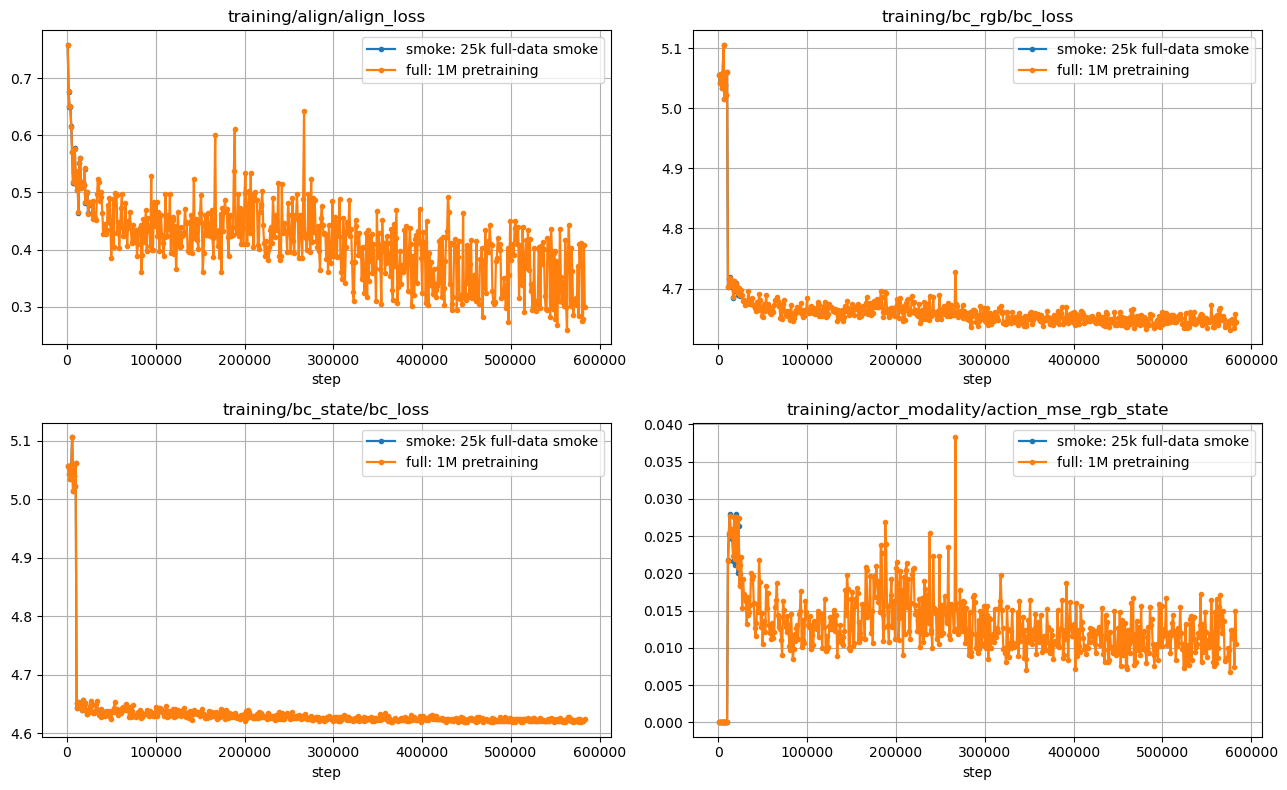

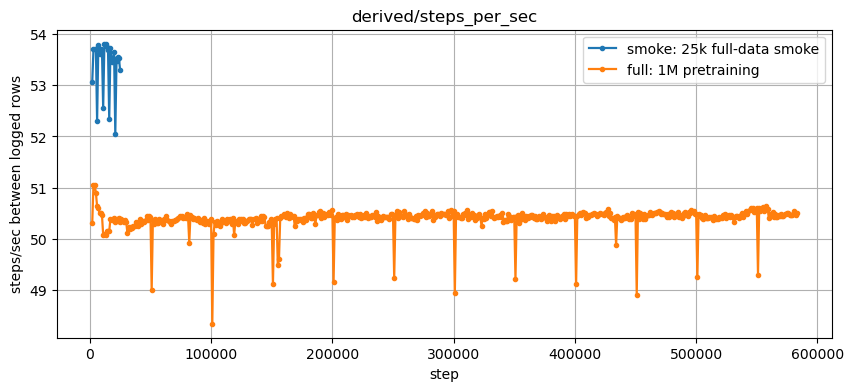

In [4]:
def plot_metric(metric: str, *, runs: tuple[str, ...] = ("smoke", "full"), smoothing: int = 1, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    for name in runs:
        df = metrics.get(name, pd.DataFrame())
        if df.empty or metric not in df.columns:
            continue
        y = pd.to_numeric(df[metric], errors="coerce")
        if smoothing and smoothing > 1:
            y = y.rolling(smoothing, min_periods=1).mean()
        ax.plot(df["step"], y, marker="o", linewidth=1.6, markersize=3, label=f"{name}: {RUNS[name]['label']}")
    ax.set_title(metric)
    ax.set_xlabel("step")
    ax.legend()
    return ax

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_metric("training/align/align_loss", ax=axes[0, 0])
plot_metric("training/bc_rgb/bc_loss", ax=axes[0, 1])
plot_metric("training/bc_state/bc_loss", ax=axes[1, 0])
plot_metric("training/actor_modality/action_mse_rgb_state", ax=axes[1, 1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_metric("derived/steps_per_sec", ax=ax)
ax.set_ylabel("steps/sec between logged rows")
plt.show()


## Interactive Metric Explorer

Use the controls to inspect one or both runs, smooth noisy metrics, and restrict the visible step range. Re-run the refresh cell above whenever the full job advances.


In [5]:
if widgets is None:
    print("ipywidgets is not available in this kernel.")
else:
    all_metric_cols = sorted({col for df in metrics.values() for col in df.columns if col != "step"})
    default_metrics = [m for m in [
        "training/align/align_loss",
        "training/bc_rgb/bc_loss",
        "training/bc_state/bc_loss",
        "training/actor_modality/action_mse_rgb_state",
    ] if m in all_metric_cols]
    run_selector = widgets.SelectMultiple(
        options=list(RUNS.keys()),
        value=tuple(RUNS.keys()),
        description="Runs",
        rows=2,
    )
    metric_selector = widgets.SelectMultiple(
        options=all_metric_cols,
        value=tuple(default_metrics[:2]),
        description="Metrics",
        rows=8,
        layout=widgets.Layout(width="75%"),
    )
    smoothing_slider = widgets.IntSlider(value=1, min=1, max=20, step=1, description="Smooth")
    max_step = int(max([df["step"].max() for df in metrics.values() if not df.empty] or [1]))
    step_slider = widgets.IntRangeSlider(value=(0, max_step), min=0, max=max_step, step=1000, description="Steps", layout=widgets.Layout(width="75%"))

    def interactive_plot(runs, metric_names, smoothing, step_range):
        if not metric_names:
            print("Select at least one metric.")
            return
        fig, axes = plt.subplots(len(metric_names), 1, figsize=(12, 3.2 * len(metric_names)), squeeze=False)
        for ax, metric_name in zip(axes[:, 0], metric_names):
            for run in runs:
                df = metrics.get(run, pd.DataFrame())
                if df.empty or metric_name not in df.columns:
                    continue
                visible = df[(df["step"] >= step_range[0]) & (df["step"] <= step_range[1])]
                if visible.empty:
                    continue
                y = pd.to_numeric(visible[metric_name], errors="coerce")
                if smoothing > 1:
                    y = y.rolling(smoothing, min_periods=1).mean()
                ax.plot(visible["step"], y, marker="o", markersize=3, linewidth=1.6, label=run)
            ax.set_title(metric_name)
            ax.set_xlabel("step")
            ax.legend()
        plt.tight_layout()
        plt.show()

    ui = widgets.VBox([run_selector, metric_selector, smoothing_slider, step_slider])
    out = widgets.interactive_output(
        interactive_plot,
        {
            "runs": run_selector,
            "metric_names": metric_selector,
            "smoothing": smoothing_slider,
            "step_range": step_slider,
        },
    )
    display(ui, out)


Output()

## Log Audit

This checks the Slurm output/error logs for high-signal events. XLA autotuning warnings are expected at startup. Hard failures are tracebacks, CUDA/JAX runtime errors, OOM, NaNs, or missing checkpoint messages after the expected interval.


In [6]:
LOG_PATTERNS = {
    "traceback": re.compile(r"Traceback|Exception", re.IGNORECASE),
    "cuda_or_jax_error": re.compile(r"CUDA error|XlaRuntimeError|RESOURCE_EXHAUSTED|jaxlib.*error|JAX CUDA preflight failed", re.IGNORECASE),
    "oom": re.compile(r"out of memory|OOM|RESOURCE_EXHAUSTED", re.IGNORECASE),
    "nan_or_inf": re.compile(r"\bnan\b|\binf\b", re.IGNORECASE),
    "checkpoint_saved": re.compile(r"Saved full training checkpoint|checkpoint", re.IGNORECASE),
    "requeue_or_signal": re.compile(r"Requeue|Received signal|Forwarding checkpoint signal", re.IGNORECASE),
    "device_cache": re.compile(r"DeviceBridgeDataset cache ready|Creating pretraining DeviceBridgeDataset", re.IGNORECASE),
    "xla_autotune_warning": re.compile(r"All configs were filtered out|autotuning", re.IGNORECASE),
}


MAX_LOG_AUDIT_BYTES = 2_000_000


def read_limited_text(path: Path, max_bytes: int = MAX_LOG_AUDIT_BYTES) -> str:
    try:
        size = path.stat().st_size
        with path.open("rb") as f:
            if size > max_bytes:
                f.seek(size - max_bytes)
                prefix = f"<truncated to last {max_bytes} bytes of {size} total bytes>\n"
            else:
                prefix = ""
            return prefix + f.read().decode("utf-8", errors="replace")
    except Exception as exc:
        return f"<could not read: {exc}>"


def read_texts(name: str) -> dict[str, str]:
    root = CACHE_ROOT / name
    texts = {}
    for path in sorted(root.rglob("*.out")) + sorted(root.rglob("*.err")) + sorted(root.rglob("slurm_status.txt")):
        texts[str(path.relative_to(root))] = read_limited_text(path)
    return texts


def audit_logs() -> tuple[pd.DataFrame, pd.DataFrame]:
    count_rows = []
    snippet_rows = []
    for name in RUNS:
        for rel, text in read_texts(name).items():
            lines = text.splitlines()
            for label, pattern in LOG_PATTERNS.items():
                matches = [(i + 1, line) for i, line in enumerate(lines) if pattern.search(line)]
                count_rows.append({"run": name, "file": rel, "pattern": label, "count": len(matches)})
                for line_no, line in matches[:5]:
                    snippet_rows.append({
                        "run": name,
                        "file": rel,
                        "pattern": label,
                        "line": line_no,
                        "snippet": textwrap.shorten(line.strip(), width=180, placeholder=" ..."),
                    })
    return pd.DataFrame(count_rows), pd.DataFrame(snippet_rows)

log_counts, log_snippets = audit_logs()
display(log_counts.pivot_table(index=["run", "file"], columns="pattern", values="count", aggfunc="sum", fill_value=0))
display(log_snippets)


pattern                                  checkpoint_saved  cuda_or_jax_error  \
run   file                                                                     
full  slurm/sd-infom-t1-s0-56857944.err                 0                  0   
      slurm/sd-infom-t1-s0-56857944.out                11                  0   
      slurm_status.txt                                  0                  0   
smoke slurm/sd-infom-t1-s0-56857200.err                 0                  0   
      slurm/sd-infom-t1-s0-56857200.out                 6                  0   
      slurm_status.txt                                  0                  0   

pattern                                  device_cache  nan_or_inf  oom  \
run   file                                                               
full  slurm/sd-infom-t1-s0-56857944.err             0           0    0   
      slurm/sd-infom-t1-s0-56857944.out             2           0    0   
      slurm_status.txt                              0           0    0   
smoke slurm/sd-infom-t1-s0-56857200.err             0           0    0   
      slurm/sd-infom-t1-s0-56857200.out             2           0    0   
      slurm_status.txt                              0           0    0   

pattern                                  requeue_or_signal  traceback  \
run   file                                                              
full  slurm/sd-infom-t1-s0-56857944.err                  0          0   
      slurm/sd-infom-t1-s0-56857944.out                  0          0   
      slurm_status.txt                                   0          0   
smoke slurm/sd-infom-t1-s0-56857200.err                  0          0   
      slurm/sd-infom-t1-s0-56857200.out                  0          0   
      slurm_status.txt                                   0          0   

pattern                                  xla_autotune_warning  
run   file                                                     
full  slurm/sd-infom-t1-s0-56857944.err                     0  
      slurm/sd-infom-t1-s0-56857944.out                     0  
      slurm_status.txt                                      0  
smoke slurm/sd-infom-t1-s0-56857200.err                     8  
      slurm/sd-infom-t1-s0-56857200.out                     0  
      slurm_status.txt                                      0

,run,file,pattern,line,snippet
0,smoke,slurm/sd-infom-t1-s0-56857200.out,checkpoint_saved,93,Saved full training checkpoint to /work/pi_men...
1,smoke,slurm/sd-infom-t1-s0-56857200.out,checkpoint_saved,94,Saved full training checkpoint to /work/pi_men...
2,smoke,slurm/sd-infom-t1-s0-56857200.out,checkpoint_saved,95,Saved full training checkpoint to /work/pi_men...
3,smoke,slurm/sd-infom-t1-s0-56857200.out,checkpoint_saved,96,Saved full training checkpoint to /work/pi_men...
4,smoke,slurm/sd-infom-t1-s0-56857200.out,checkpoint_saved,97,Saved full training checkpoint to /work/pi_men...
5,smoke,slurm/sd-infom-t1-s0-56857200.out,device_cache,91,Creating pretraining DeviceBridgeDataset cache...
6,smoke,slurm/sd-infom-t1-s0-56857200.out,device_cache,92,pretraining DeviceBridgeDataset cache ready: 1...
7,smoke,slurm/sd-infom-t1-s0-56857200.err,xla_autotune_warning,5,"0%| | 0/25000 [00:00<?, ?it/s]2026-05-06 21:28..."
8,smoke,slurm/sd-infom-t1-s0-56857200.err,xla_autotune_warning,6,2026-05-06 21:28:05.196943: W external/xla/xla...
9,smoke,slurm/sd-infom-t1-s0-56857200.err,xla_autotune_warning,7,2026-05-06 21:28:05.196999: W external/xla/xla...


## Checkpoint And Resume Readiness

For the smoke run, checkpoints were saved every 5k, but the submitter keeps only the most recent four training-state files plus `latest.pkl`; the earliest 5k file can be pruned after 25k. For the full 1M run, the first scheduled checkpoint is at 50k and then every 50k. These are full training checkpoints, not model-only snapshots, so they are suitable for auto-resume/requeue.


In [7]:
def load_checkpoint_listing(name: str) -> pd.DataFrame:
    path = CACHE_ROOT / name / "checkpoint_listing.json"
    if not path.exists():
        return pd.DataFrame(columns=["run", "date", "time", "file", "bytes"])
    return pd.DataFrame(json.loads(path.read_text()))

checkpoint_df = pd.concat([load_checkpoint_listing(name) for name in RUNS], ignore_index=True)
if not checkpoint_df.empty:
    checkpoint_df["mb"] = checkpoint_df["bytes"] / (1024 ** 2)
    checkpoint_df["step"] = pd.to_numeric(checkpoint_df["file"].str.extract(r"training_state_(\d+)\.pkl")[0], errors="coerce")
    display(checkpoint_df.sort_values(["run", "file"]))
else:
    display(Markdown("No checkpoints found in the current cache. Re-run the refresh cell."))

expected_rows = []
for name, spec in RUNS.items():
    df = metrics.get(name, pd.DataFrame())
    last_step = int(df["step"].max()) if not df.empty else 0
    expected_saved_ckpts = last_step // spec["checkpoint_interval"]
    expected_retained_ckpts = min(expected_saved_ckpts, spec.get("checkpoint_keep", expected_saved_ckpts))
    observed_ckpts = checkpoint_df[(checkpoint_df["run"] == name) & checkpoint_df["file"].str.startswith("training_state_")].shape[0] if not checkpoint_df.empty else 0
    expected_rows.append({
        "run": name,
        "last_step": last_step,
        "checkpoint_interval": spec["checkpoint_interval"],
        "checkpoint_keep": spec.get("checkpoint_keep"),
        "expected_saved_training_state_ckpts_by_now": expected_saved_ckpts,
        "expected_retained_training_state_ckpts": expected_retained_ckpts,
        "observed_training_state_ckpts": observed_ckpts,
        "latest_present": bool((checkpoint_df["run"].eq(name) & checkpoint_df["file"].eq("latest.pkl")).any()) if not checkpoint_df.empty else False,
    })
display(pd.DataFrame(expected_rows))


,bytes,date,file,run,time,mb,step
10,94505238,2026-05-07,latest.pkl,full,00:46:36.9094048070,90.127218,NaN
5,94505239,2026-05-06,training_state_0000350000.pkl,full,23:40:30.2916240240,90.127219,350000.0
6,94505238,2026-05-06,training_state_0000400000.pkl,full,23:57:02.3671211180,90.127218,400000.0
7,94505239,2026-05-07,training_state_0000450000.pkl,full,00:13:34.2291102450,90.127219,450000.0
8,94505239,2026-05-07,training_state_0000500000.pkl,full,00:30:05.2772854930,90.127219,500000.0
9,94505238,2026-05-07,training_state_0000550000.pkl,full,00:46:36.7485317340,90.127218,550000.0
4,94505224,2026-05-06,latest.pkl,smoke,21:36:21.9203530740,90.127205,NaN
0,94505228,2026-05-06,training_state_0000010000.pkl,smoke,21:31:40.1916032860,90.127209,10000.0
1,94505229,2026-05-06,training_state_0000015000.pkl,smoke,21:33:13.6271530700,90.127210,15000.0
2,94505228,2026-05-06,training_state_0000020000.pkl,smoke,21:34:47.4206295330,90.127209,20000.0


,run,last_step,checkpoint_interval,checkpoint_keep,expected_saved_training_state_ckpts_by_now,expected_retained_training_state_ckpts,observed_training_state_ckpts,latest_present
0,smoke,25000,5000,4,5,4,4,True
1,full,583000,50000,5,11,5,5,True


## TensorBoard

TensorBoard is useful for live monitoring while the notebook gives a compact audit trail. After running the refresh cell, a local copy of the current event files is available under the notebook cache. For truly live tracking, run TensorBoard on Unity or refresh this cache periodically.


In [8]:
for name, spec in RUNS.items():
    local_tb = local_path(name, spec["tensorboard_rel"])
    remote_tb = f"{spec['remote_root'].rstrip('/')}/{spec['tensorboard_rel']}"
    print(f"[{name}] local copied logdir:")
    print(f"  tensorboard --logdir {shlex.quote(str(local_tb))}")
    print(f"[{name}] remote logdir:")
    print(f"  {remote_tb}")
    print()

watch = [
    "training/align/align_loss",
    "training/bc_rgb/bc_loss",
    "training/bc_state/bc_loss",
    "training/actor_modality/action_mse_rgb_state",
    "time/epoch_time",
    "time/total_time",
]
print("Main scalar tags to watch:")
for item in watch:
    print(" -", item)


[smoke] local copied logdir:
  tensorboard --logdir /home/nick/infom-learning-from-obs/output/jupyter-notebook/cache/state_distilled_method_a_monitor/smoke/runs/state_distilled_method_a_diagnostic/task1_seed0_25kpre_0kft/tensorboard
[smoke] remote logdir:
  /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_diag_20260506_172510/runs/state_distilled_method_a_diagnostic/task1_seed0_25kpre_0kft/tensorboard

[full] local copied logdir:
  tensorboard --logdir /home/nick/infom-learning-from-obs/output/jupyter-notebook/cache/state_distilled_method_a_monitor/full/runs/state_distilled_method_a_diagnostic/task1_seed0_1000kpre_0kft/tensorboard
[full] remote logdir:
  /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/state_distilled_method_a_diag_20260506_173753/runs/state_distilled_method_a_diagnostic/task1_seed0_1000kpre_0kft/tensorboard

Main scalar tags to watch:
 - training/align/align_loss
 - training/bc_rgb/bc_loss
 - tra

## Interpretation Notes

Evidence so far supports the device-cache implementation and the current hardware strategy:

- The smoke run completed and saved full checkpoints through 25k plus `latest.pkl`.
- The full run initialized the 23.15 GiB device cache on an A100 40GB node, validating the target under-40GB memory path.
- Early full-run metrics match the smoke trajectory: alignment loss decreases, RGB/state BC losses stay close, and RGB-state action disagreement stays low.
- XLA autotuning warnings appear during startup and are not by themselves a failure. Hard failures to watch are tracebacks, CUDA runtime errors, OOM, NaNs, or missing scheduled checkpoints.

Remaining limits:

- This is pretraining-only. It does not establish task success until the matching fine-tuning/evaluation stage runs.
- The full job is running under normal QOS because it had already started cleanly. New short/debug/gating jobs should use `--qos=short` whenever they fit under Unity's limits.


## Short-QOS Operating Rule For The Next Jobs

Use Unity `--qos=short` for short debug, audit, smoke, and gating jobs when no other short-QOS job is active. Keep time under four hours and nodes at two or fewer. Prefer `h100|a100|l40s`; request a full high-end node only when independent processes can safely occupy separate GPUs inside the same Slurm job. For long work, split into checkpointed chunks when practical, otherwise use normal QOS with full checkpoint/resume enabled.


## Method B TCN/InfoNCE Monitor

This section tracks the backup Method B implementation: trainable state/RGB encoders aligned with symmetric InfoNCE, InFOM on RGB shared latents, and state-only evaluation. It includes the local routing smoke and the Unity short-QOS smoke.

In [9]:
METHOD_B_CACHE_ROOT = REPO_ROOT / "output" / "jupyter-notebook" / "cache" / "cross_modal_tcn_method_b_monitor"
METHOD_B_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

METHOD_B_RUNS = {
    "method_b_local_smoke": {
        "source": "local",
        "label": "Method B local CPU routing smoke",
        "local_root": str(REPO_ROOT / "runs/tmp/cross_modal_tcn_main_smoke/method_b_smoke/tiny_cpu"),
        "pretrain_rel": "pretraining_train.csv",
        "finetune_rel": "finetuning_train.csv",
        "tensorboard_rel": "tensorboard",
        "checkpoint_rel": "checkpoints",
        "expected_pretrain_step": 2,
        "checkpoint_interval": 1,
        "checkpoint_keep": 2,
    },
    "method_b_short_smoke": {
        "source": "remote",
        "job_id": "56872490",
        "label": "Method B 25k short-QOS smoke",
        "remote_root": "/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/cross_modal_tcn_method_b_diag_20260506_203701",
        "pretrain_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_25kpre_0kft/pretraining_train.csv",
        "finetune_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_25kpre_0kft/finetuning_train.csv",
        "tensorboard_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_25kpre_0kft/tensorboard",
        "checkpoint_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_25kpre_0kft/checkpoints",
        "expected_pretrain_step": 25_000,
        "checkpoint_interval": 5_000,
        "checkpoint_keep": 4,
    },
    "method_b_full": {
        "source": "remote",
        "job_id": "56874321",
        "label": "Method B 1M short-QOS pretraining",
        "remote_root": "/work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/cross_modal_tcn_method_b_diag_20260506_205707",
        "pretrain_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_1000kpre_0kft/pretraining_train.csv",
        "finetune_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_1000kpre_0kft/finetuning_train.csv",
        "tensorboard_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_1000kpre_0kft/tensorboard",
        "checkpoint_rel": "runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_1000kpre_0kft/checkpoints",
        "expected_pretrain_step": 1_000_000,
        "checkpoint_interval": 50_000,
        "checkpoint_keep": 5,
    },
}

display(pd.DataFrame([
    {"run": name, **{k: v for k, v in spec.items() if k in ["source", "job_id", "label", "expected_pretrain_step", "checkpoint_interval"]}}
    for name, spec in METHOD_B_RUNS.items()
]))

,run,source,label,expected_pretrain_step,checkpoint_interval,job_id
0,method_b_local_smoke,local,Method B local CPU routing smoke,2,1,NaN
1,method_b_short_smoke,remote,Method B 25k short-QOS smoke,25000,5000,56872490
2,method_b_full,remote,Method B 1M short-QOS pretraining,1000000,50000,56874321


In [10]:
def method_b_cache_path(name: str) -> Path:
    return METHOD_B_CACHE_ROOT / name


def method_b_artifact_path(name: str, rel: str) -> Path:
    spec = METHOD_B_RUNS[name]
    if spec["source"] == "local":
        return Path(spec["local_root"]) / rel
    return method_b_cache_path(name) / rel


def method_b_rsync(name: str, spec: dict) -> dict:
    if spec["source"] == "local":
        root = Path(spec["local_root"])
        return {"run": name, "returncode": 0 if root.exists() else 1, "output": "local", "local_root": str(root)}
    local_root = method_b_cache_path(name)
    local_root.mkdir(parents=True, exist_ok=True)
    remote_root = spec["remote_root"].rstrip("/") + "/"
    cmd = [
        "rsync", "-az", "--prune-empty-dirs",
        "--include=*/",
        "--include=*.csv",
        "--include=*.out",
        "--include=*.err",
        "--include=*.json",
        "--include=events.out.tfevents.*",
        "--exclude=*.pkl",
        "--exclude=*",
        f"{SSH_HOST}:{remote_root}",
        str(local_root) + "/",
    ]
    proc = run_command(cmd, timeout=240)
    return {"run": name, "returncode": proc.returncode, "output": proc.stdout.strip(), "local_root": str(local_root)}


def method_b_checkpoint_listing(name: str, spec: dict) -> list[dict]:
    if spec["source"] == "local":
        checkpoint_dir = Path(spec["local_root"]) / spec["checkpoint_rel"]
        rows = []
        for path in sorted(checkpoint_dir.glob("*.pkl")):
            stat = path.stat()
            rows.append({"run": name, "file": path.name, "bytes": stat.st_size, "date": "local", "time": "local"})
    else:
        checkpoint_dir = f"{spec['remote_root'].rstrip('/')}/{spec['checkpoint_rel']}"
        command = (
            f"find {shlex.quote(checkpoint_dir)} -maxdepth 1 -type f "
            "-printf '%TY-%Tm-%Td %TH:%TM:%TS %f %s\n' 2>/dev/null | sort"
        )
        proc = ssh(command, timeout=60)
        rows = []
        for line in proc.stdout.splitlines():
            match = re.match(r"(\d{4}-\d{2}-\d{2}) (\d{2}:\d{2}:\d{2}(?:\.\d+)?) (\S+) (\d+)$", line.strip())
            if match:
                rows.append({"run": name, "date": match.group(1), "time": match.group(2), "file": match.group(3), "bytes": int(match.group(4))})
    listing_path = method_b_cache_path(name) / "checkpoint_listing.json"
    listing_path.parent.mkdir(parents=True, exist_ok=True)
    listing_path.write_text(json.dumps(rows, indent=2, sort_keys=True) + "\n")
    return rows


def method_b_slurm_status(name: str, spec: dict) -> str:
    if spec["source"] == "local":
        return "LOCAL_RUN\n"
    return slurm_status(spec["job_id"])


def method_b_refresh_all() -> pd.DataFrame:
    rows = []
    for name, spec in METHOD_B_RUNS.items():
        sync_result = method_b_rsync(name, spec)
        checkpoints = method_b_checkpoint_listing(name, spec)
        status = method_b_slurm_status(name, spec)
        status_path = method_b_cache_path(name) / "slurm_status.txt"
        status_path.parent.mkdir(parents=True, exist_ok=True)
        status_path.write_text(status)
        rows.append({
            "run": name,
            "source": spec["source"],
            "job_id": spec.get("job_id", ""),
            "rsync_code": sync_result["returncode"],
            "checkpoint_files": len(checkpoints),
            "local_root": sync_result["local_root"],
            "status_head": " | ".join(status.splitlines()[:3]),
        })
    return pd.DataFrame(rows)

method_b_refresh_df = method_b_refresh_all()
display(method_b_refresh_df)

,run,source,job_id,rsync_code,checkpoint_files,local_root,status_head
0,method_b_local_smoke,local,,0,3,/home/nick/infom-learning-from-obs/runs/tmp/cr...,LOCAL_RUN
1,method_b_short_smoke,remote,56872490,0,5,/home/nick/infom-learning-from-obs/output/jupy...,SQUEUE_ACTIVE | JOBID PARTITIO...
2,method_b_full,remote,56874321,0,0,/home/nick/infom-learning-from-obs/output/jupy...,SQUEUE_ACTIVE | JOBID PARTITIO...


In [11]:
def method_b_load_csv(name: str, rel_key: str) -> pd.DataFrame:
    rel = METHOD_B_RUNS[name].get(rel_key)
    if not rel:
        return pd.DataFrame()
    path = method_b_artifact_path(name, rel)
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (TypeError, ValueError):
            pass
    if "step" in df:
        df = df.sort_values("step").reset_index(drop=True)
    return add_throughput(df)

method_b_pretrain = {name: method_b_load_csv(name, "pretrain_rel") for name in METHOD_B_RUNS}
method_b_finetune = {name: method_b_load_csv(name, "finetune_rel") for name in METHOD_B_RUNS}

summary_rows = []
for name, df in method_b_pretrain.items():
    spec = METHOD_B_RUNS[name]
    if df.empty:
        summary_rows.append({"run": name, "rows": 0, "status": "no pretraining CSV yet"})
        continue
    first = df.iloc[0]
    last = df.iloc[-1]
    elapsed = float(last.get("time/total_time", np.nan))
    first_elapsed = float(first.get("time/total_time", np.nan))
    step_gain = float(last["step"] - first["step"])
    elapsed_gain = elapsed - first_elapsed
    rate = step_gain / elapsed_gain if elapsed_gain > 0 else np.nan
    summary_rows.append({
        "run": name,
        "rows": len(df),
        "first_step": int(first["step"]),
        "last_step": int(last["step"]),
        "progress_%": 100 * float(last["step"]) / spec["expected_pretrain_step"],
        "infonce_first": float(first.get("training/infonce/loss", np.nan)),
        "infonce_last": float(last.get("training/infonce/loss", np.nan)),
        "s2rgb_acc_last": float(last.get("training/infonce/current_retrieval_acc_state_to_rgb", np.nan)),
        "rgb2s_acc_last": float(last.get("training/infonce/current_retrieval_acc_rgb_to_state", np.nan)),
        "pos_sim_last": float(last.get("training/infonce/current_positive_similarity", np.nan)),
        "neg_sim_last": float(last.get("training/infonce/current_negative_similarity_mean", np.nan)),
        "rgb_bc_last": float(last.get("training/bc_rgb/bc_loss", np.nan)),
        "state_bc_last": float(last.get("training/bc_state/bc_loss", np.nan)),
        "action_mse_last": float(last.get("training/actor_modality/action_mse_rgb_state", np.nan)),
        "flow_loss_last": float(last.get("training/flow_occupancy/neg_elbo_loss", np.nan)),
        "steps_per_sec_window": rate,
        "eta_hours_at_window_rate": (spec["expected_pretrain_step"] - float(last["step"])) / rate / 3600 if rate > 0 else np.nan,
    })
method_b_summary = pd.DataFrame(summary_rows)
display(method_b_summary)

,run,rows,first_step,last_step,progress_%,infonce_first,infonce_last,s2rgb_acc_last,rgb2s_acc_last,pos_sim_last,neg_sim_last,rgb_bc_last,state_bc_last,action_mse_last,flow_loss_last,steps_per_sec_window,eta_hours_at_window_rate,status
0,method_b_local_smoke,2,1.0,2.0,100.0,4.222123,2.942066,0.5,0.25,-0.006558,-0.033057,4.791060,4.790638,0.000072,0.021680,39.918380,0.0,NaN
1,method_b_short_smoke,50,500.0,25000.0,100.0,1.205922,0.085440,1.0,1.00,0.959368,0.000690,4.704986,4.637083,0.024821,0.007766,49.607848,0.0,NaN
2,method_b_full,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no pretraining CSV yet


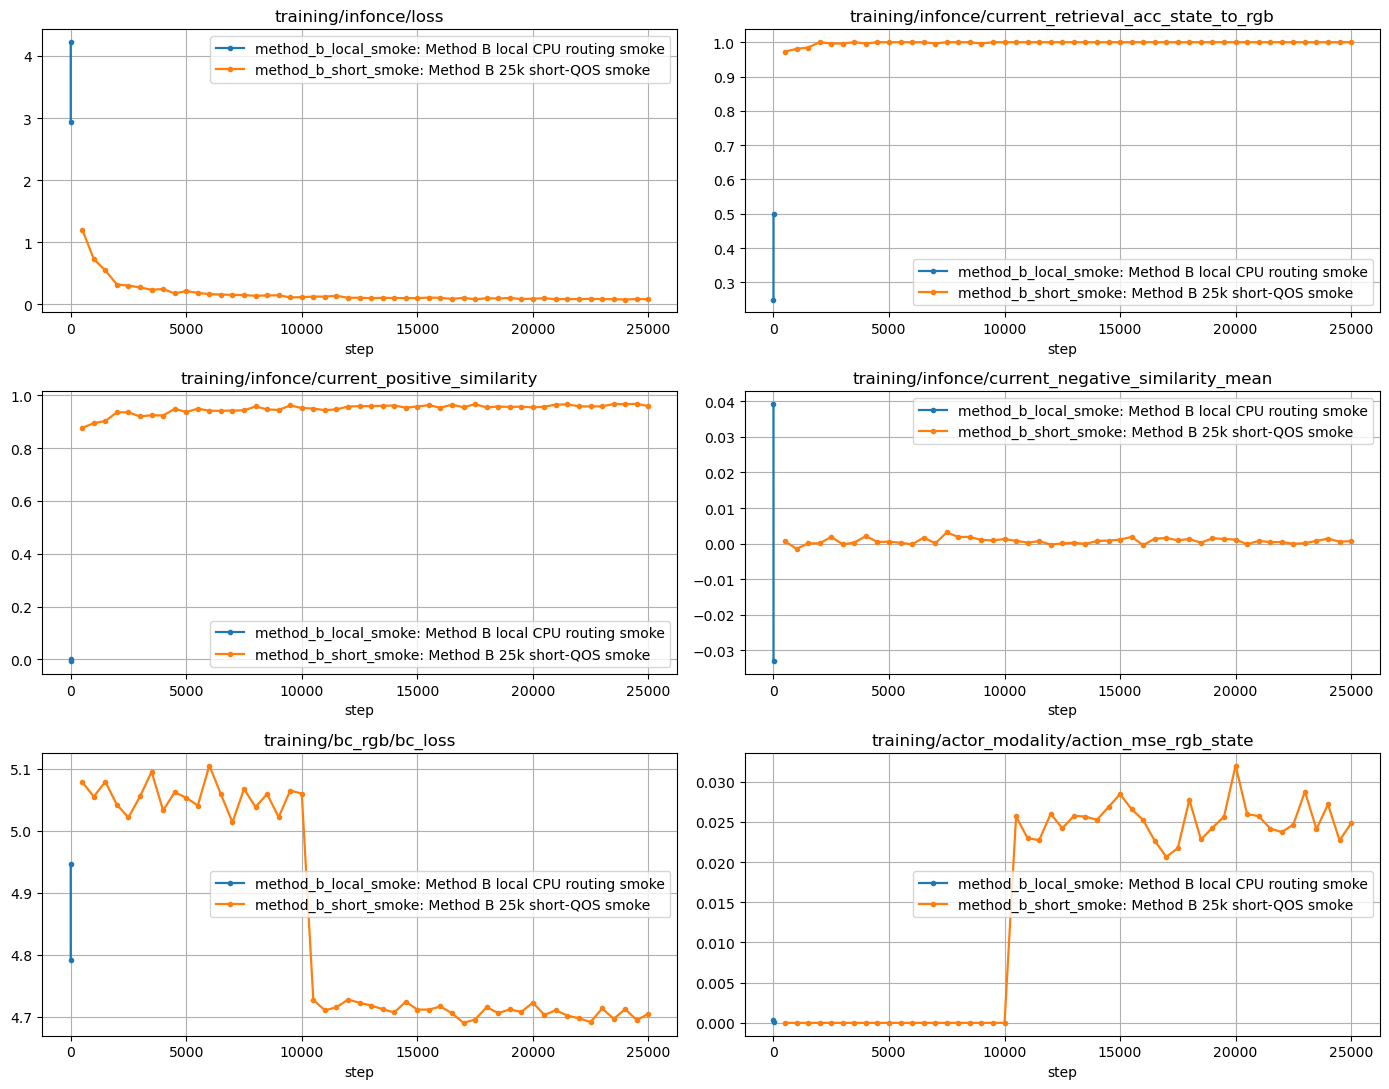

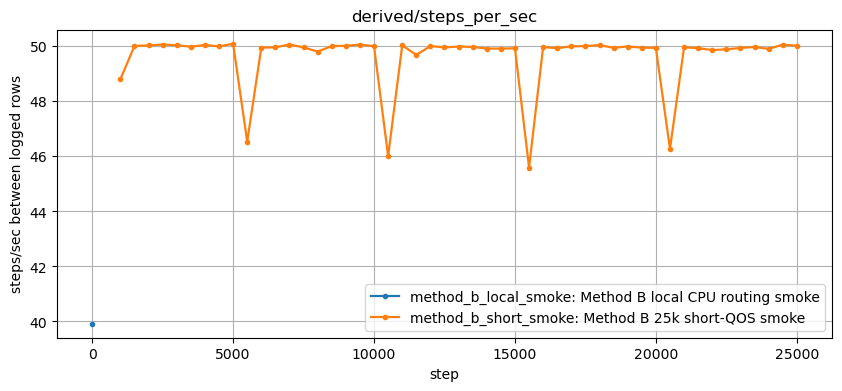

In [12]:
def plot_method_b_metric(metric: str, *, runs: tuple[str, ...] | None = None, smoothing: int = 1, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    runs = tuple(METHOD_B_RUNS.keys()) if runs is None else runs
    for name in runs:
        df = method_b_pretrain.get(name, pd.DataFrame())
        if df.empty or metric not in df.columns:
            continue
        y = pd.to_numeric(df[metric], errors="coerce")
        if smoothing and smoothing > 1:
            y = y.rolling(smoothing, min_periods=1).mean()
        ax.plot(df["step"], y, marker="o", linewidth=1.6, markersize=3, label=f"{name}: {METHOD_B_RUNS[name]['label']}")
    ax.set_title(metric)
    ax.set_xlabel("step")
    ax.legend()
    return ax

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
plot_method_b_metric("training/infonce/loss", ax=axes[0, 0])
plot_method_b_metric("training/infonce/current_retrieval_acc_state_to_rgb", ax=axes[0, 1])
plot_method_b_metric("training/infonce/current_positive_similarity", ax=axes[1, 0])
plot_method_b_metric("training/infonce/current_negative_similarity_mean", ax=axes[1, 1])
plot_method_b_metric("training/bc_rgb/bc_loss", ax=axes[2, 0])
plot_method_b_metric("training/actor_modality/action_mse_rgb_state", ax=axes[2, 1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_method_b_metric("derived/steps_per_sec", ax=ax)
ax.set_ylabel("steps/sec between logged rows")
plt.show()

In [13]:
method_b_checkpoint_df = pd.concat([
    pd.DataFrame(json.loads((method_b_cache_path(name) / "checkpoint_listing.json").read_text()))
    if (method_b_cache_path(name) / "checkpoint_listing.json").exists()
    else pd.DataFrame(columns=["run", "date", "time", "file", "bytes"])
    for name in METHOD_B_RUNS
], ignore_index=True)
if not method_b_checkpoint_df.empty:
    method_b_checkpoint_df["mb"] = method_b_checkpoint_df["bytes"] / (1024 ** 2)
    method_b_checkpoint_df["step"] = pd.to_numeric(method_b_checkpoint_df["file"].str.extract(r"training_state_(\d+)\.pkl")[0], errors="coerce")
    display(method_b_checkpoint_df.sort_values(["run", "file"]))
else:
    display(Markdown("No Method B checkpoints found yet. Re-run refresh after the Slurm job starts."))

for name, spec in METHOD_B_RUNS.items():
    local_tb = method_b_artifact_path(name, spec["tensorboard_rel"])
    print(f"[{name}] TensorBoard logdir:")
    print(f"  tensorboard --logdir {shlex.quote(str(local_tb))}")
    if spec["source"] == "remote":
        print(f"  remote: {spec['remote_root'].rstrip('/')}/{spec['tensorboard_rel']}")
    print()

print("Method B scalar tags to watch:")
for item in [
    "training/infonce/loss",
    "training/infonce/current_retrieval_acc_state_to_rgb",
    "training/infonce/current_retrieval_acc_rgb_to_state",
    "training/infonce/current_positive_similarity",
    "training/infonce/current_negative_similarity_mean",
    "training/bc_rgb/bc_loss",
    "training/bc_state/bc_loss",
    "training/actor_modality/action_mse_rgb_state",
    "training/flow_occupancy/neg_elbo_loss",
    "derived/steps_per_sec",
]:
    print(" -", item)

,bytes,date,file,run,time,mb,step
0,6516667,local,latest.pkl,method_b_local_smoke,local,6.214778,NaN
1,6516672,local,training_state_0000000002.pkl,method_b_local_smoke,local,6.214783,2.0
2,6516667,local,training_state_0000000003.pkl,method_b_local_smoke,local,6.214778,3.0
7,139884071,2026-05-07,latest.pkl,method_b_short_smoke,00:55:16.6737631760,133.403846,NaN
3,139884075,2026-05-07,training_state_0000010000.pkl,method_b_short_smoke,00:50:13.2094626840,133.403850,10000.0
4,139884075,2026-05-07,training_state_0000015000.pkl,method_b_short_smoke,00:51:54.1842724800,133.403850,15000.0
5,139884075,2026-05-07,training_state_0000020000.pkl,method_b_short_smoke,00:53:35.1330595750,133.403850,20000.0
6,139884071,2026-05-07,training_state_0000025000.pkl,method_b_short_smoke,00:55:16.4822624410,133.403846,25000.0


[method_b_local_smoke] TensorBoard logdir:
  tensorboard --logdir /home/nick/infom-learning-from-obs/runs/tmp/cross_modal_tcn_main_smoke/method_b_smoke/tiny_cpu/tensorboard

[method_b_short_smoke] TensorBoard logdir:
  tensorboard --logdir /home/nick/infom-learning-from-obs/output/jupyter-notebook/cache/cross_modal_tcn_method_b_monitor/method_b_short_smoke/runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_25kpre_0kft/tensorboard
  remote: /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/cross_modal_tcn_method_b_diag_20260506_203701/runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_25kpre_0kft/tensorboard

[method_b_full] TensorBoard logdir:
  tensorboard --logdir /home/nick/infom-learning-from-obs/output/jupyter-notebook/cache/cross_modal_tcn_method_b_monitor/method_b_full/runs/cross_modal_tcn_method_b_diagnostic/task1_seed0_1000kpre_0kft/tensorboard
  remote: /work/pi_mengfanxu_umass_edu/bhuo_umass_edu/infom-learning-from-obs/runs/cross_modal_tcn_method_b

### Method B Reading Guide

For the Method B smoke, the first pass is not about success rate yet. The run is healthy if InfoNCE loss drops from its random-batch scale, retrieval accuracy rises above random, positive pair similarity separates from negative-pair similarity, RGB/state BC losses stay finite, action disagreement does not blow up, flow loss stays finite, and checkpoints appear at the scheduled 5k cadence. If InfoNCE improves but BC/action consistency is poor, the shared latent may be alignable but not policy-useful. If retrieval stays random and positive/negative similarities do not separate, the state/RGB pairing, augmentation, batch construction, or objective wiring needs diagnosis before a full 1M run.